DESCRIPCION DEL PROBELEMA 

El presente análisis se centra en un conjunto de datos históricos del Banco de la República, que recoge información mensual desde 1998 sobre distintos tipos de créditos (consumo, tesorería, ordinarios y preferenciales) y las tasas de colocación asociadas (Banco de la República, sin tesorería y total). La variable Fecha constituye el eje temporal que organiza las observaciones y permite estudiar la evolución de estos indicadores financieros a lo largo de más de dos décadas. Este carácter secuencial convierte al dataset en una serie de tiempo, ideal para explorar tendencias, ciclos y posibles patrones de estacionalidad en el comportamiento del crédito y las tasas de interés en Colombia. El objetivo del análisis exploratorio será identificar regularidades, cambios estructurales y relaciones entre las diferentes modalidades de crédito y las tasas de colocación, como paso previo a la construcción de modelos predictivos y de interpretación económica.

Importaciones

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np


#importacion del data set
df =  pd.read_excel(r"C:/Users/jacob/OneDrive/Escritorio/Datasets/File.xlsx",skiprows=4)


# renombramos columnas
df.columns = [
    "Fecha",
    "CreditosConsumo",
    "CreditosTesoreria",
    "CreditosOrdinarios",
    "CreditosPreferenciales",
    "TasaColocacionBR",
    "TasaColocacionSinTesoreria",
    "TasaColocacionTotal"
]

# tomamos desde la cuarto fila debido a que las anteriores no nos sirven
#df = df.iloc[4:].reset_index(drop=True)

df = df.dropna(subset=['Fecha'])
df = df.dropna()
# Eliminamos las filas vacias
df.head()


ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

Veamos una descripcion breve de las variables

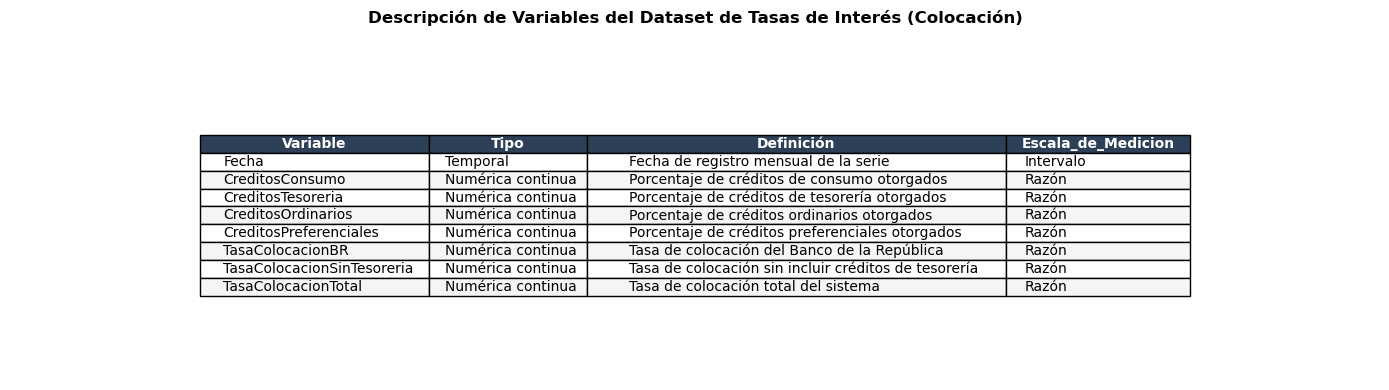

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

data = {
    "Variable": [
        "Fecha", "CreditosConsumo", "CreditosTesoreria", "CreditosOrdinarios",
        "CreditosPreferenciales", "TasaColocacionBR", "TasaColocacionSinTesoreria", "TasaColocacionTotal"
    ],
    "Tipo": [
        "Temporal", "Numérica continua", "Numérica continua", "Numérica continua",
        "Numérica continua", "Numérica continua", "Numérica continua", "Numérica continua"
    ],
    "Definición": [
        "Fecha de registro mensual de la serie",
        "Porcentaje de créditos de consumo otorgados",
        "Porcentaje de créditos de tesorería otorgados",
        "Porcentaje de créditos ordinarios otorgados",
        "Porcentaje de créditos preferenciales otorgados",
        "Tasa de colocación del Banco de la República",
        "Tasa de colocación sin incluir créditos de tesorería",
        "Tasa de colocación total del sistema"
    ],
    "Escala_de_Medicion": [
        "Intervalo", "Razón", "Razón", "Razón", "Razón", "Razón", "Razón", "Razón"
    ]
}

df_tabla = pd.DataFrame(data)

fig, ax = plt.subplots(figsize=(14, 4))
ax.axis('off')

tabla = ax.table(
    cellText=df_tabla.values,
    colLabels=df_tabla.columns,
    cellLoc='left',
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.auto_set_column_width(col=list(range(len(df_tabla.columns))))

# Estilo encabezado
for j in range(len(df_tabla.columns)):
    tabla[0, j].set_facecolor("#2E4057")
    tabla[0, j].set_text_props(color="white", fontweight="bold")

# Filas alternas
for i in range(1, len(df_tabla) + 1):
    color = "#F5F5F5" if i % 2 == 0 else "white"
    for j in range(len(df_tabla.columns)):
        tabla[i, j].set_facecolor(color)

plt.title("Descripción de Variables del Dataset de Tasas de Interés (Colocación)",
          fontsize=12, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("tabla_variables_EDA.png", dpi=150, bbox_inches="tight")
plt.show()

Caracteristicas del DataSet

Estructura

In [13]:

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 329
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       330 non-null    object 
 1   CreditosConsumo             330 non-null    float64
 2   CreditosTesoreria           330 non-null    float64
 3   CreditosOrdinarios          330 non-null    float64
 4   CreditosPreferenciales      330 non-null    float64
 5   TasaColocacionBR            330 non-null    float64
 6   TasaColocacionSinTesoreria  330 non-null    float64
 7   TasaColocacionTotal         330 non-null    float64
dtypes: float64(7), object(1)
memory usage: 23.2+ KB


Primeras 5 filas(vista previa)

In [14]:

df.head()

,Fecha,CreditosConsumo,CreditosTesoreria,CreditosOrdinarios,CreditosPreferenciales,TasaColocacionBR,TasaColocacionSinTesoreria,TasaColocacionTotal
0,1998-03-31 00:00:00,42.241660,37.219532,36.461227,35.195714,37.140147,37.120547,37.175234
1,1998-04-30 00:00:00,44.080287,41.613687,38.817179,39.644168,40.600564,40.307819,41.079538
2,1998-05-31 00:00:00,45.316060,37.788361,40.291468,36.325765,39.683262,40.085468,38.902765
3,1998-06-30 00:00:00,48.410011,56.408795,47.077058,49.560814,50.487852,48.343274,53.539534
4,1998-07-31 00:00:00,51.567193,42.686869,48.101190,45.519187,46.401729,47.915642,44.408194


Dimensiones

In [15]:
df.shape

(330, 8)

El dataset cuenta con 8 variables todas numericas con 330 observaciones, se asemeja a un panel temporal que registra la evolución de distintos tipos de créditos y tasas de colocación en el sistema financiero lo cual serveria para un analisis. La varibale Fecha es fundamental ya que en ella se fundamentara nuestro analisis como serie temporal 

Veamos cuantos datos faltantes hay como tal

In [16]:
df.isnull().sum()

Fecha                         0
CreditosConsumo               0
CreditosTesoreria             0
CreditosOrdinarios            0
CreditosPreferenciales        0
TasaColocacionBR              0
TasaColocacionSinTesoreria    0
TasaColocacionTotal           0
dtype: int64

Aca podemos observar que nuestro dataset no presenta ningun tipo de valor faltante lo que nos ayudara a la realizacion de la serie de Tiempo de manera mas efectiva 

ANALISIS UNIVARIADO

Tasa De colocacion total

       Media    Mediana  Desviacion_Estandar    Minimo     Maximo
0  14.712434  12.801609             6.661249  8.163828  53.539534


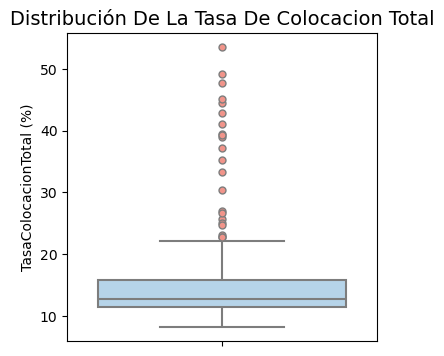

In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["TasaColocacionTotal"].mean(skipna=True),
    "Mediana": df["TasaColocacionTotal"].median(skipna=True),
    "Desviacion_Estandar": df["TasaColocacionTotal"].std(skipna=True),
    "Minimo": df["TasaColocacionTotal"].min(skipna=True),
    "Maximo": df["TasaColocacionTotal"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["TasaColocacionTotal"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("TasaColocacionTotal (%)")
ax.set_title("Distribución De La Tasa De Colocacion Total", fontsize=14)
plt.show()


La variable Tesorería de Colocación Total, que será nuestro objetivo de predicción frente a la variable de tiempo, presenta un promedio de 14.7 y una mediana de 12.8, lo que evidencia una ligera asimetría positiva, ya que algunos valores altos elevan la media por encima de la mediana; la desviación estándar de 6.66 refleja una variabilidad moderada, mientras que el rango entre el mínimo de 8.16 y el máximo de 53.5 muestra tanto periodos de tasas relativamente bajas como episodios de tasas muy elevadas. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que la tesorería de colocación total ha tenido un comportamiento con cierta estabilidad en torno a valores medios, pero con picos que responden a coyunturas macroeconómicas específicas, como crisis financieras, ajustes de política monetaria o presiones inflacionarias. Este patrón es fundamental para tu análisis exploratorio, ya que al ser la variable que se busca predecir, la combinación de estadísticas descriptivas y la representación gráfica en el tiempo permitirá identificar tendencias, ciclos y cambios estructurales, preparando el terreno para modelos predictivos que capturen la dinámica y sensibilidad del sistema financiero colombiano frente a variaciones en las condiciones de mercado.


Creditos De Consumo

       Media    Mediana  Desviacion_Estandar     Minimo     Maximo
0  23.122029  19.950215             7.641846  13.548079  52.310139


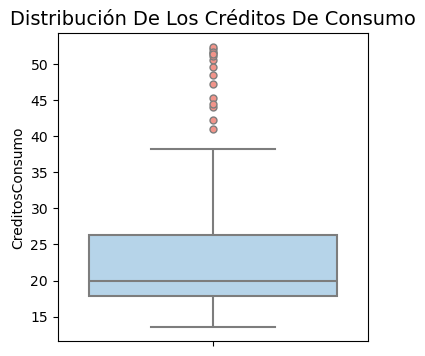

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["CreditosConsumo"].mean(skipna=True),
    "Mediana": df["CreditosConsumo"].median(skipna=True),
    "Desviacion_Estandar": df["CreditosConsumo"].std(skipna=True),
    "Minimo": df["CreditosConsumo"].min(skipna=True),
    "Maximo": df["CreditosConsumo"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["CreditosConsumo"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("CreditosConsumo")
ax.set_title("Distribución De Los Créditos De Consumo", fontsize=14)
plt.show()


La variable Créditos de Consumo presenta un promedio de 23.1 y una mediana de 20, lo que evidencia una distribución asimétrica positiva en la que algunos valores altos elevan la media; la desviación estándar de 7.64 refleja una variabilidad moderada, mientras que el rango entre el mínimo de 13.5 y el máximo de 52.3 confirma episodios de expansión y contracción del crédito a lo largo de más de dos décadas de datos mensuales del Banco de la República. En el contexto de una serie temporal, estas estadísticas sugieren que el crédito de consumo ha estado expuesto a ciclos de auge y restricción influenciados por factores macroeconómicos como tasas de interés, inflación y crisis financieras, lo que convierte su análisis en un punto de partida para identificar tendencias, cambios estructurales y relaciones con otras modalidades de crédito y tasas de colocación, preparando el terreno para modelos predictivos que capturen la dinámica y sensibilidad de este mercado en Colombia.

Creditos De Tesoreria

       Media   Mediana  Desviacion_Estandar    Minimo     Maximo
0  11.573796  9.455916             6.990951  5.559112  56.408795


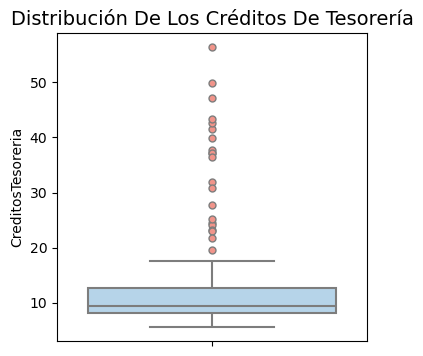

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["CreditosTesoreria"].mean(skipna=True),
    "Mediana": df["CreditosTesoreria"].median(skipna=True),
    "Desviacion_Estandar": df["CreditosTesoreria"].std(skipna=True),
    "Minimo": df["CreditosTesoreria"].min(skipna=True),
    "Maximo": df["CreditosTesoreria"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["CreditosTesoreria"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("CreditosTesoreria")
ax.set_title("Distribución De Los Créditos De Tesorería", fontsize=14)
plt.show()


La variable Créditos de Tesorería muestra un promedio de 11.6 y una mediana de 9.46, lo que indica nuevamente una distribución con ligera asimetría positiva, pues los valores altos elevan la media por encima de la mediana; la desviación estándar de 6.99 refleja una variabilidad moderada, aunque algo menor que la observada en los créditos de consumo, y el rango entre el mínimo de 5.56 y el máximo de 56.4 evidencia episodios de fuerte expansión en ciertos periodos frente a fases de baja colocación. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que los créditos de tesorería han tenido un comportamiento más concentrado en valores bajos, pero con picos ocasionales que responden a condiciones macroeconómicas específicas, como necesidades de liquidez de las empresas o ajustes en las tasas de interés. Este patrón, menos estable que el de consumo pero con mayor dispersión relativa en los extremos, constituye un punto de partida para analizar la sensibilidad de esta modalidad frente a shocks financieros y su relación con otras formas de crédito, preparando el terreno para detectar ciclos, cambios estructurales y construir modelos predictivos que capturen su dinámica en el sistema financiero colombiano.

Creditos Ordinarios

       Media    Mediana  Desviacion_Estandar    Minimo     Maximo
0  15.602229  14.303238              7.16558  6.886727  49.494947


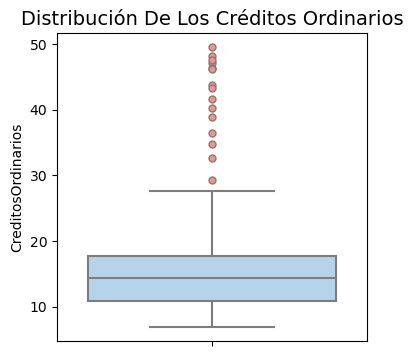

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["CreditosOrdinarios"].mean(skipna=True),
    "Mediana": df["CreditosOrdinarios"].median(skipna=True),
    "Desviacion_Estandar": df["CreditosOrdinarios"].std(skipna=True),
    "Minimo": df["CreditosOrdinarios"].min(skipna=True),
    "Maximo": df["CreditosOrdinarios"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["CreditosOrdinarios"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("CreditosOrdinarios")
ax.set_title("Distribución De Los Créditos Ordinarios", fontsize=14)
plt.show()


La variable Créditos Ordinarios presenta un promedio de 15.6 y una mediana de 14.3, lo que indica una distribución con ligera asimetría positiva, pues algunos valores altos elevan la media por encima de la mediana; la desviación estándar de 7.17 refleja una variabilidad moderada, mientras que el rango entre el mínimo de 6.89 y el máximo de 49.5 evidencia tanto periodos de baja colocación como episodios de expansión significativa. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que los créditos ordinarios han mostrado un comportamiento relativamente estable en torno a valores medios, pero con picos ocasionales que responden a condiciones macroeconómicas o coyunturales específicas. Este patrón, menos extremo que el de tesorería pero con mayor dispersión que el de consumo, constituye un insumo clave para identificar tendencias, ciclos y posibles cambios estructurales en el sistema financiero colombiano, así como para preparar modelos predictivos que capturen su dinámica y sensibilidad frente a tasas de interés y otros factores económicos.


Creditos Preferenciales

       Media    Mediana  Desviacion_Estandar    Minimo     Maximo
0  12.046822  10.575737             7.231437  4.335672  49.560814


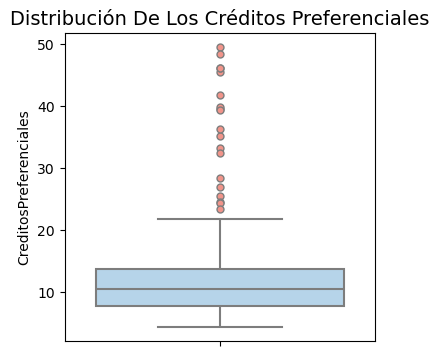

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["CreditosPreferenciales"].mean(skipna=True),
    "Mediana": df["CreditosPreferenciales"].median(skipna=True),
    "Desviacion_Estandar": df["CreditosPreferenciales"].std(skipna=True),
    "Minimo": df["CreditosPreferenciales"].min(skipna=True),
    "Maximo": df["CreditosPreferenciales"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["CreditosPreferenciales"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("CreditosPreferenciales")
ax.set_title("Distribución De Los Créditos Preferenciales", fontsize=14)
plt.show()


La variable Créditos Preferenciales presenta un promedio de 12.0 y una mediana de 10.6, lo que refleja una ligera asimetría positiva, ya que algunos valores altos elevan la media por encima de la mediana; la desviación estándar de 7.23 indica una variabilidad moderada, mientras que el rango entre el mínimo de 4.34 y el máximo de 49.6 evidencia tanto periodos de baja colocación como episodios de expansión significativa. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que los créditos preferenciales han tenido un comportamiento más concentrado en valores bajos, pero con picos ocasionales que responden a condiciones macroeconómicas específicas o políticas de financiamiento dirigidas a ciertos sectores. Este patrón, con mayor dispersión relativa en los extremos, constituye un insumo clave para identificar tendencias, ciclos y posibles cambios estructurales en el sistema financiero colombiano, así como para preparar modelos predictivos que capturen su dinámica y sensibilidad frente a tasas de interés y otros factores económicos.


Tasa De Colocacion BR

       Media    Mediana  Desviacion_Estandar    Minimo     Maximo
0  15.505212  14.281585             6.845193  8.202934  50.487852


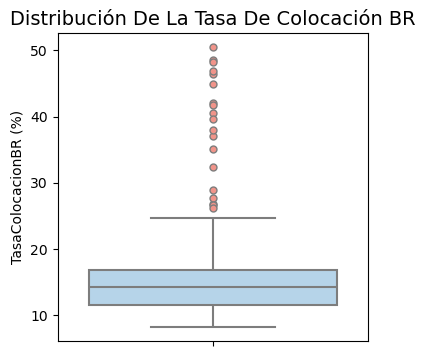

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["TasaColocacionBR"].mean(skipna=True),
    "Mediana": df["TasaColocacionBR"].median(skipna=True),
    "Desviacion_Estandar": df["TasaColocacionBR"].std(skipna=True),
    "Minimo": df["TasaColocacionBR"].min(skipna=True),
    "Maximo": df["TasaColocacionBR"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["TasaColocacionBR"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("TasaColocacionBR (%)")
ax.set_title("Distribución De La Tasa De Colocación BR", fontsize=14)
plt.show()


La variable Tasa de Colocación del Banco de la República presenta un promedio de 15.5 y una mediana de 14.3, lo que indica una ligera asimetría positiva, pues algunos valores altos elevan la media por encima de la mediana; la desviación estándar de 6.85 refleja una variabilidad moderada, mientras que el rango entre el mínimo de 8.20 y el máximo de 50.5 evidencia tanto periodos de tasas relativamente bajas como episodios de tasas muy elevadas. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que la tasa de colocación ha tenido un comportamiento con cierta estabilidad en torno a valores medios, pero con picos que responden a coyunturas macroeconómicas específicas, como crisis financieras, ajustes de política monetaria o presiones inflacionarias. Este patrón es fundamental para el análisis exploratorio, ya que permite relacionar la evolución de las tasas con la dinámica de los distintos tipos de crédito, identificar ciclos y cambios estructurales en la política monetaria, y preparar modelos predictivos que capturen la sensibilidad del sistema financiero colombiano frente a variaciones en las condiciones de mercado.

Tasa De Colocacion Sin Tesoreria

       Media    Mediana  Desviacion_Estandar    Minimo     Maximo
0  15.886567  14.389636             7.027249  8.213002  48.671404


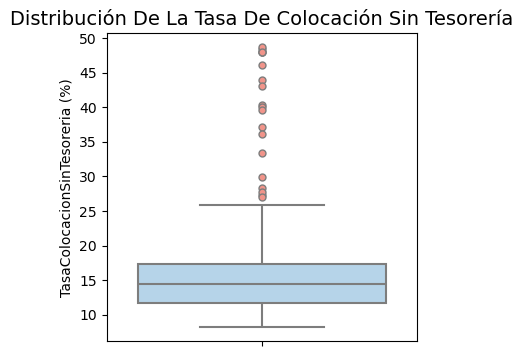

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Resumen estadístico ---
resumen = {
    "Media": df["TasaColocacionSinTesoreria"].mean(skipna=True),
    "Mediana": df["TasaColocacionSinTesoreria"].median(skipna=True),
    "Desviacion_Estandar": df["TasaColocacionSinTesoreria"].std(skipna=True),
    "Minimo": df["TasaColocacionSinTesoreria"].min(skipna=True),
    "Maximo": df["TasaColocacionSinTesoreria"].max(skipna=True)
}
resumen_df = pd.DataFrame([resumen])
print(resumen_df)

# --- Boxplot ---
fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(
    y=df["TasaColocacionSinTesoreria"],
    ax=ax,
    color="#AED6F1",
    linewidth=1.5,
    flierprops=dict(marker='o', markerfacecolor='#F1948A', markersize=5)
)
ax.set_ylabel("TasaColocacionSinTesoreria (%)")
ax.set_title("Distribución De La Tasa De Colocación Sin Tesorería", fontsize=14)
plt.show()


La variable Tasa de Colocación sin Tesorería presenta un promedio de 15.9 y una mediana de 14.4, lo que refleja una ligera asimetría positiva, ya que algunos valores altos elevan la media por encima de la mediana; la desviación estándar de 7.03 indica una variabilidad moderada, mientras que el rango entre el mínimo de 8.21 y el máximo de 48.7 evidencia tanto periodos de tasas relativamente bajas como episodios de tasas elevadas. En el contexto de la serie temporal mensual desde 1998, estos resultados sugieren que la tasa de colocación sin tesorería ha mostrado un comportamiento relativamente estable en torno a valores medios, pero con picos que responden a coyunturas macroeconómicas específicas, como ajustes de política monetaria, presiones inflacionarias o crisis financieras. Este patrón constituye un insumo clave para el análisis exploratorio, ya que permite relacionar la evolución de las tasas con la dinámica de los distintos tipos de crédito, identificar ciclos y cambios estructurales en la política monetaria, y preparar modelos predictivos que capturen la sensibilidad del sistema financiero colombiano frente a variaciones en las condiciones de mercado.


ANALISIS BIVARIADO

Tasa de Colocacion Total VS Creditos Consumo

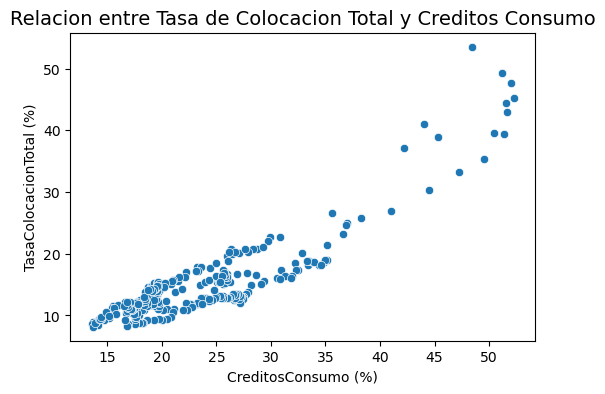

In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["CreditosConsumo"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Creditos Consumo", fontsize=14)
ax.set_xlabel("CreditosConsumo (%)")
ax.set_ylabel("TasaColocacionTotal (%)")

plt.show()

Este diagrama de dispersión muestra la relación entre la Tasa de Colocación Total y los Créditos de Consumo, con una clara tendencia positiva: a mayor volumen de créditos de consumo, mayor tasa de colocación total. Aunque no se ha calculado la correlación estadística, la visualización sugiere una asociación significativa, lo que convierte a los créditos de consumo en un factor relevante para explicar y anticipar el comportamiento de la tasa de colocación total en futuros modelos predictivos.

Tasa de Colocacion Total VS Creditos Tesoreria

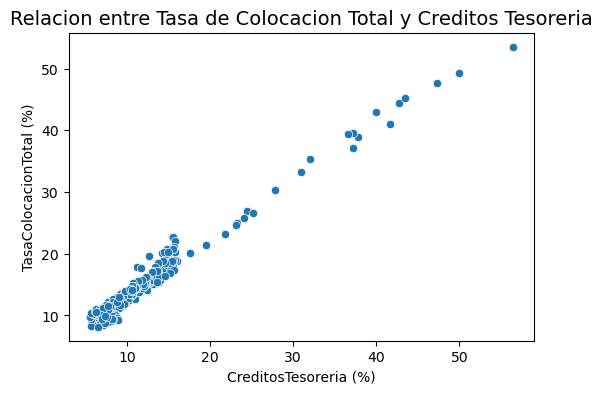

In [25]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["CreditosTesoreria"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Creditos Tesoreria", fontsize=14)
ax.set_xlabel("CreditosTesoreria (%)")
ax.set_ylabel("TasaColocacionTotal (%)")
plt.show()

Este diagrama de dispersión muestra la relación entre la Tasa de Colocación Total y los Créditos de Tesorería; aunque no se ha calculado la correlación numérica, la visualización sugiere una asociación positiva, donde mayores créditos de tesorería se acompañan de incrementos en la tasa de colocación total. Este patrón indica que la tesorería influye directamente en la dinámica de las tasas y constituye un insumo clave para confirmar la relación mediante un cálculo formal de correlación y para futuros modelos predictivos.

Tasa de Colocacion Total VS Creditos Ordinarios

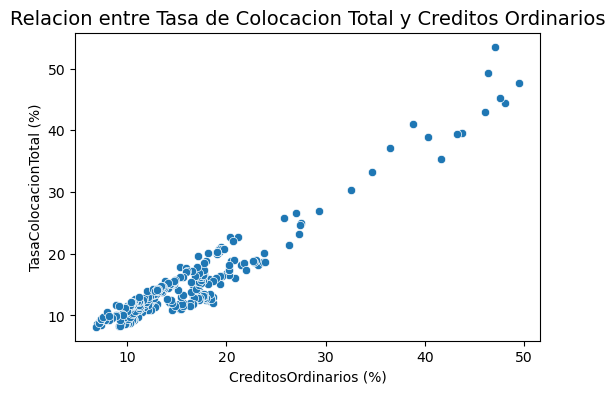

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["CreditosOrdinarios"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Creditos Ordinarios", fontsize=14)
ax.set_xlabel("CreditosOrdinarios (%)")
ax.set_ylabel("TasaColocacionTotal (%)")
plt.show()

Este diagrama de dispersión muestra la relación entre la Tasa de Colocación Total y los Créditos Ordinarios; aunque no se ha calculado la correlación numérica, la visualización sugiere una asociación positiva, donde mayores créditos ordinarios tienden a acompañarse de incrementos en la tasa de colocación total. Este patrón señala que los créditos ordinarios son un factor relevante en la dinámica de las tasas y constituye un insumo clave para confirmar la relación mediante un cálculo formal de correlación y para futuros modelos predictivos.

Tasa de Colocacion Total VS Creditos Preferenciales

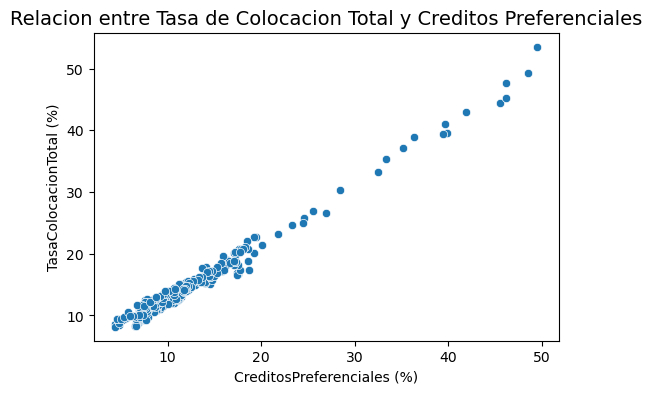

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["CreditosPreferenciales"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Creditos Preferenciales", fontsize=14)
ax.set_xlabel("CreditosPreferenciales (%)")
ax.set_ylabel("TasaColocacionTotal (%)")
plt.show()

Este diagrama de dispersión muestra una asociación positiva entre la Tasa de Colocación Total y los Créditos Preferenciales; mayores volúmenes de créditos preferenciales tienden a acompañarse de incrementos en la tasa, lo que señala su influencia en la dinámica financiera y la necesidad de confirmar la relación con un cálculo formal de correlación para futuros modelos predictivos.

Tasa de Colocacion Total VS Tasa Colocacion BR

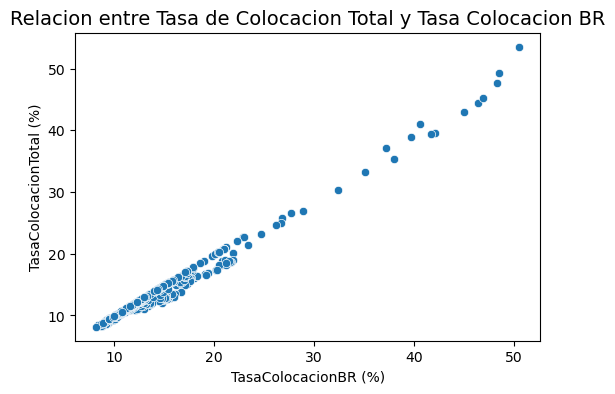

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["TasaColocacionBR"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Tasa Colocacion BR", fontsize=14)
ax.set_xlabel("TasaColocacionBR (%)")
ax.set_ylabel("TasaColocacionTotal (%)")
plt.show()

Este diagrama de dispersión muestra la relación entre la Tasa de Colocación Total y la Tasa de Colocación del Banco de la República (BR); aunque aún no se ha calculado la correlación numérica, la visualización sugiere una asociación positiva clara, donde incrementos en la tasa de colocación del BR tienden a acompañarse de incrementos en la tasa de colocación total. Este patrón es consistente con la lógica financiera, ya que las decisiones de política monetaria del Banco de la República influyen directamente en las condiciones de colocación del sistema, y constituye un insumo clave para confirmar la relación mediante un cálculo formal de correlación y para futuros modelos predictivos que busquen capturar la sensibilidad del mercado frente a variaciones en las tasas oficiales.

Tasa de Colocacion Total VS Tasa Colocacion Sin Tesoreria

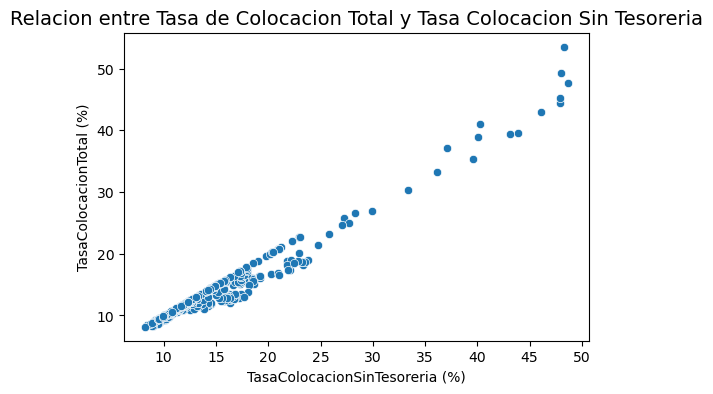

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x=df["TasaColocacionSinTesoreria"],
    y=df["TasaColocacionTotal"],
    ax=ax
)
ax.set_title("Relacion entre Tasa de Colocacion Total y Tasa Colocacion Sin Tesoreria", fontsize=14)
ax.set_xlabel("TasaColocacionSinTesoreria (%)")
ax.set_ylabel("TasaColocacionTotal (%)")
plt.show()

Este diagrama muestra una asociación positiva entre la Tasa de Colocación Total y la Tasa de Colocación sin Tesorería; mayores valores en la tasa sin tesorería se acompañan de incrementos en la tasa total, reflejando condiciones financieras comunes y la influencia de factores macroeconómicos, lo que debe confirmarse con un cálculo formal de correlación para fortalecer futuros modelos predictivos.

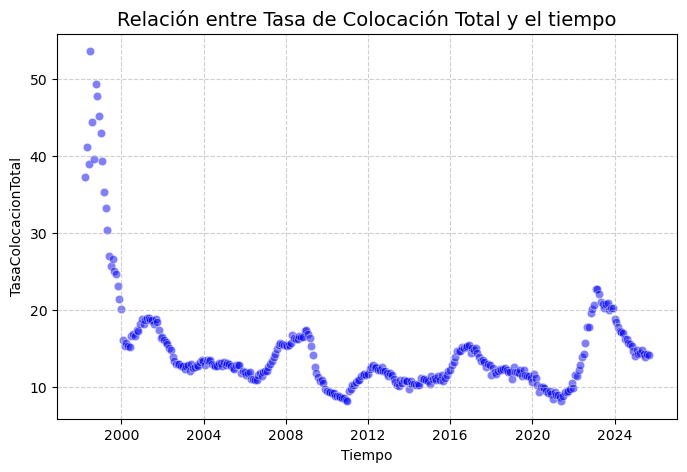

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Gráfico de dispersión ---
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Fecha",
    y="TasaColocacionTotal",
    alpha=0.5,
    color="blue"
)

plt.title("Relación entre Tasa de Colocación Total y el tiempo", fontsize=14)
plt.xlabel("Tiempo")
plt.ylabel("TasaColocacionTotal")
plt.grid(True, linestyle="--", alpha=0.6)  # estilo similar a theme_minimal
plt.show()


Este gráfico de dispersión muestra la evolución de la Tasa de Colocación Total a lo largo del tiempo, donde se distinguen varias fases: a finales de los 90 e inicios de los 2000 se observan niveles muy altos con un pico marcado, seguido de una caída significativa y un periodo de relativa estabilidad en valores más bajos; entre 2010 y 2020 aparecen fluctuaciones con picos intermedios que sugieren ciclos de ajuste en la política monetaria o respuesta a crisis económicas; y alrededor de 2020 se aprecia otro repunte posiblemente asociado a coyunturas como la pandemia. En conjunto, el gráfico evidencia que la tasa no es estacionaria, sino que responde a shocks y tendencias macroeconómicas, lo que confirma la necesidad de un análisis temporal más profundo antes de aplicar modelos predictivos que capturen tanto la tendencia como los ciclos y cambios estructurales del sistema financiero colombiano.

# FIN